## 06 Random Forest

In [4]:
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# target is 'AHD'
df = pd.read_csv("../../data/Heart.csv", index_col=0)
df.head()

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 303 entries, 1 to 303
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        303 non-null    int64  
 1   Sex        303 non-null    int64  
 2   ChestPain  303 non-null    object 
 3   RestBP     303 non-null    int64  
 4   Chol       303 non-null    int64  
 5   Fbs        303 non-null    int64  
 6   RestECG    303 non-null    int64  
 7   MaxHR      303 non-null    int64  
 8   ExAng      303 non-null    int64  
 9   Oldpeak    303 non-null    float64
 10  Slope      303 non-null    int64  
 11  Ca         299 non-null    float64
 12  Thal       301 non-null    object 
 13  AHD        303 non-null    object 
dtypes: float64(2), int64(9), object(3)
memory usage: 35.5+ KB


In [6]:
# missing values: either drop or fill
df_no_nulls = df.dropna()

df_no_nulls.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 1 to 302
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        297 non-null    int64  
 1   Sex        297 non-null    int64  
 2   ChestPain  297 non-null    object 
 3   RestBP     297 non-null    int64  
 4   Chol       297 non-null    int64  
 5   Fbs        297 non-null    int64  
 6   RestECG    297 non-null    int64  
 7   MaxHR      297 non-null    int64  
 8   ExAng      297 non-null    int64  
 9   Oldpeak    297 non-null    float64
 10  Slope      297 non-null    int64  
 11  Ca         297 non-null    float64
 12  Thal       297 non-null    object 
 13  AHD        297 non-null    object 
dtypes: float64(2), int64(9), object(3)
memory usage: 34.8+ KB


In [7]:


df_no_nulls["AHD"].value_counts()

AHD
No     160
Yes    137
Name: count, dtype: int64

In [9]:
pd.get_dummies(df_no_nulls)
# make dummies (one hot encoding)

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,ChestPain_asymptomatic,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Thal_fixed,Thal_normal,Thal_reversable,AHD_No,AHD_Yes
1,63,1,145,233,1,2,150,0,2.3,3,0.0,False,False,False,True,True,False,False,True,False
2,67,1,160,286,0,2,108,1,1.5,2,3.0,True,False,False,False,False,True,False,False,True
3,67,1,120,229,0,2,129,1,2.6,2,2.0,True,False,False,False,False,False,True,False,True
4,37,1,130,250,0,0,187,0,3.5,3,0.0,False,True,False,False,False,True,False,True,False
5,41,0,130,204,0,2,172,0,1.4,1,0.0,False,False,True,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,140,241,0,0,123,1,0.2,2,0.0,True,False,False,False,False,False,True,False,True
299,45,1,110,264,0,0,132,0,1.2,2,0.0,False,False,False,True,False,False,True,False,True
300,68,1,144,193,1,0,141,0,3.4,2,2.0,True,False,False,False,False,False,True,False,True
301,57,1,130,131,0,0,115,1,1.2,2,1.0,True,False,False,False,False,False,True,False,True


In [11]:
df_dummies = pd.get_dummies(df_no_nulls, drop_first=True)
df_dummies.head()

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Thal_normal,Thal_reversable,AHD_Yes
1,63,1,145,233,1,2,150,0,2.3,3,0.0,False,False,True,False,False,False
2,67,1,160,286,0,2,108,1,1.5,2,3.0,False,False,False,True,False,True
3,67,1,120,229,0,2,129,1,2.6,2,2.0,False,False,False,False,True,True
4,37,1,130,250,0,0,187,0,3.5,3,0.0,True,False,False,True,False,False
5,41,0,130,204,0,2,172,0,1.4,1,0.0,False,True,False,True,False,False


#### here do plotting, heatmaps, histgram, pairplots to EDA

### Split data

In [12]:
X, y = df_dummies.drop("AHD_Yes", axis=1), df_dummies["AHD_Yes"]
X.head()

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Thal_normal,Thal_reversable
1,63,1,145,233,1,2,150,0,2.3,3,0.0,False,False,True,False,False
2,67,1,160,286,0,2,108,1,1.5,2,3.0,False,False,False,True,False
3,67,1,120,229,0,2,129,1,2.6,2,2.0,False,False,False,False,True
4,37,1,130,250,0,0,187,0,3.5,3,0.0,True,False,False,True,False
5,41,0,130,204,0,2,172,0,1.4,1,0.0,False,True,False,True,False


In [13]:
y.head()

1    False
2     True
3     True
4    False
5    False
Name: AHD_Yes, dtype: bool

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

X_train.shape, X_test.shape


((198, 16), (99, 16))

## Model training 
- note no feature scaling for Random Forest

In [18]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred[:10] # for guesses: 8/10

array([False,  True, False,  True, False, False,  True,  True,  True,
       False])

In [19]:
y_test[:10].values # facit

array([False,  True, False,  True, False, False, False, False,  True,
       False])

## Evaluation

              precision    recall  f1-score   support

       False       0.82      0.85      0.83        53
        True       0.82      0.78      0.80        46

    accuracy                           0.82        99
   macro avg       0.82      0.82      0.82        99
weighted avg       0.82      0.82      0.82        99



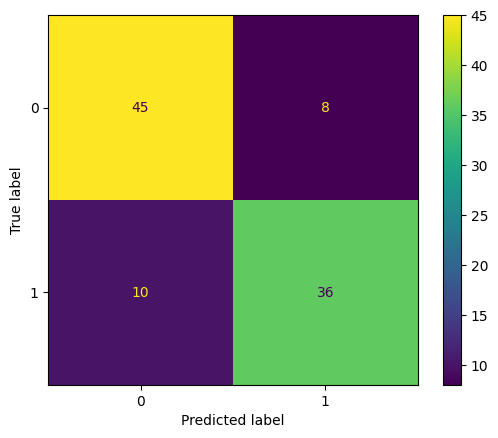

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print(classification_report(y_test, y_pred))
cm= confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()

### note compare different algorithms against one another

## Feature importance

In [22]:
# weighting of various features in dataset
model.feature_importances_

array([0.08142281, 0.03167121, 0.07104603, 0.10252733, 0.00841005,
       0.01803257, 0.11830048, 0.03773407, 0.09850533, 0.01769564,
       0.17086867, 0.04629344, 0.01059185, 0.01686747, 0.10628195,
       0.0637511 ])

In [24]:
X.columns # for comparison, name of feature below and weight above

Index(['Age', 'Sex', 'RestBP', 'Chol', 'Fbs', 'RestECG', 'MaxHR', 'ExAng',
       'Oldpeak', 'Slope', 'Ca', 'ChestPain_nonanginal',
       'ChestPain_nontypical', 'ChestPain_typical', 'Thal_normal',
       'Thal_reversable'],
      dtype='object')

In [27]:
feature_importance = pd.DataFrame([X.columns, model.feature_importances_])
feature_importance

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Thal_normal,Thal_reversable
1,0.081423,0.031671,0.071046,0.102527,0.00841,0.018033,0.1183,0.037734,0.098505,0.017696,0.170869,0.046293,0.010592,0.016867,0.106282,0.063751


In [30]:
feature_importance = feature_importance.T
feature_importance.columns = ["Feature", "Importance"]

ValueError: Length mismatch: Expected axis has 16 elements, new values have 2 elements

In [ ]:
feature_importance = feature_importance